In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

##Importing Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("irfanahammad/telecom-churn-15k-dataset")

print("Path to dataset files:", path)

100%|██████████| 542k/542k [00:00<00:00, 22.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/irfanahammad/telecom-churn-15k-dataset/versions/1


In [3]:
import os
print(os.listdir(path))

['telecom_churn_15000.csv']


In [4]:
df=pd.read_csv(path+'/telecom_churn_15000.csv')
df.head()

,CustomerID,Age,Gender,State,TenureMonths,MonthlyCharges,TotalCharges,DataUsageGB,CallMinutes,SMSCount,...,NetworkComplaints,LatePayments,PlanType,ContractType,PaymentMethod,FamilyPlan,InternationalCalls,DeviceAgeMonths,AvgMonthlyRecharge,Churn
0,CUST000001,56,Female,Bihar,38,2516.76,91265.06,2.23,4936,2684,...,3,1,Premium,TwoYear,UPI,No,No,35,2539.25,No
1,CUST000002,69,Male,Chhattisgarh,49,2261.33,101500.80,72.01,4052,1456,...,5,0,Basic,Yearly,Credit Card,No,No,31,2551.49,No
2,CUST000003,46,Male,Uttarakhand,117,3914.37,453065.54,80.20,1094,2143,...,10,0,Basic,Monthly,UPI,No,No,2,1316.32,No
3,CUST000004,32,Male,Rajasthan,94,2125.41,189857.54,162.83,4934,1523,...,5,0,Standard,Monthly,Net Banking,No,No,22,3458.94,No
4,CUST000005,60,Female,Gujarat,28,1662.31,44946.21,47.52,887,1217,...,4,1,Basic,TwoYear,Credit Card,No,No,22,147.96,No


In [5]:
df.tail(3)

,CustomerID,Age,Gender,State,TenureMonths,MonthlyCharges,TotalCharges,DataUsageGB,CallMinutes,SMSCount,...,NetworkComplaints,LatePayments,PlanType,ContractType,PaymentMethod,FamilyPlan,InternationalCalls,DeviceAgeMonths,AvgMonthlyRecharge,Churn
14997,CUST014998,61,Male,Andhra Pradesh,36,4728.65,176001.82,236.44,2994,2166,...,10,3,Basic,TwoYear,Credit Card,No,No,54,2188.09,Yes
14998,CUST014999,36,Female,Jharkhand,46,1536.05,73978.43,172.09,1789,2223,...,10,2,Basic,Monthly,Net Banking,No,No,59,2551.58,Yes
14999,CUST015000,25,Male,Maharashtra,42,2886.44,121346.94,242.90,2471,1175,...,12,7,Standard,Monthly,UPI,No,No,52,1932.91,No


##EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            15000 non-null  object 
 1   Age                   15000 non-null  int64  
 2   Gender                15000 non-null  object 
 3   State                 15000 non-null  object 
 4   TenureMonths          15000 non-null  int64  
 5   MonthlyCharges        15000 non-null  float64
 6   TotalCharges          15000 non-null  float64
 7   DataUsageGB           15000 non-null  float64
 8   CallMinutes           15000 non-null  int64  
 9   SMSCount              15000 non-null  int64  
 10  CustomerSupportCalls  15000 non-null  int64  
 11  NetworkComplaints     15000 non-null  int64  
 12  LatePayments          15000 non-null  int64  
 13  PlanType              15000 non-null  object 
 14  ContractType          15000 non-null  object 
 15  PaymentMethod      

In [7]:
df.describe()

,Age,TenureMonths,MonthlyCharges,TotalCharges,DataUsageGB,CallMinutes,SMSCount,CustomerSupportCalls,NetworkComplaints,LatePayments,DeviceAgeMonths,AvgMonthlyRecharge
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,43.920400,60.689533,2555.007285,147119.550741,150.021048,2500.430867,1505.385467,10.027067,7.507333,5.917267,30.667200,2015.910085
std,15.180526,34.817367,1413.141739,126015.040141,86.785445,1437.299916,865.077153,6.053746,4.591516,3.733812,17.264497,1141.857495
min,18.000000,1.000000,100.040000,153.410000,0.040000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,50.090000
25%,31.000000,30.000000,1332.095000,42528.822500,74.060000,1253.750000,752.000000,5.000000,4.000000,3.000000,16.000000,1033.177500
50%,44.000000,61.000000,2568.440000,111708.405000,151.125000,2522.000000,1516.500000,10.000000,7.000000,6.000000,31.000000,2020.045000
75%,57.000000,91.000000,3782.200000,225143.740000,225.890000,3735.000000,2255.000000,15.000000,11.000000,9.000000,45.000000,3003.172500
max,70.000000,120.000000,4999.790000,603705.520000,299.960000,5000.000000,3000.000000,20.000000,15.000000,12.000000,60.000000,3999.890000


In [8]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
State,0
TenureMonths,0
MonthlyCharges,0
TotalCharges,0
DataUsageGB,0
CallMinutes,0
SMSCount,0


In [9]:
df.groupby('Gender')["Churn"].value_counts()

Gender  Churn
Female  No       4875
        Yes      1989
Male    No       5877
        Yes      2259
Name: count, dtype: int64

In [10]:
df.groupby('PlanType')["Churn"].value_counts()

PlanType  Churn
Basic     No       3518
          Yes      1624
Premium   No       2901
          Yes       917
Standard  No       4333
          Yes      1707
Name: count, dtype: int64

In [11]:
df.groupby('Churn')["NetworkComplaints"].mean()

,NetworkComplaints
Churn,
No,7.080450
Yes,8.587806


In [12]:
df.groupby("Churn")["FamilyPlan"].value_counts()

Churn  FamilyPlan
No     No            6286
       Yes           4466
Yes    No            3046
       Yes           1202
Name: count, dtype: int64

In [13]:
df.groupby("Churn")["LatePayments"].mean()

,LatePayments
Churn,
No,5.628813
Yes,6.647363


##Visualize

<Axes: xlabel='Gender', ylabel='DeviceAgeMonths'>

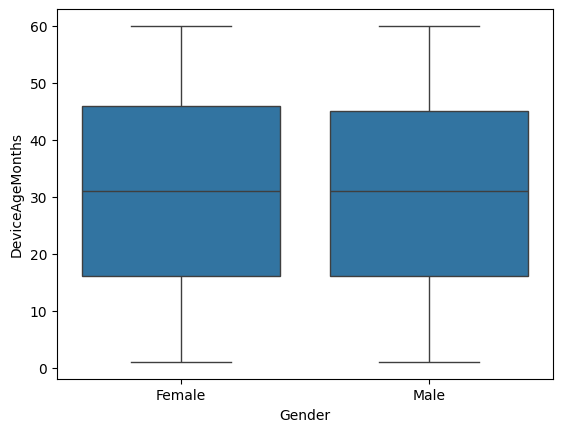

In [14]:
sns.boxplot(data=df,x='Gender',y='DeviceAgeMonths')

In [15]:
df.groupby('Gender')["PlanType"].value_counts()

Gender  PlanType
Female  Standard    2790
        Basic       2340
        Premium     1734
Male    Standard    3250
        Basic       2802
        Premium     2084
Name: count, dtype: int64

<Axes: xlabel='Gender', ylabel='count'>

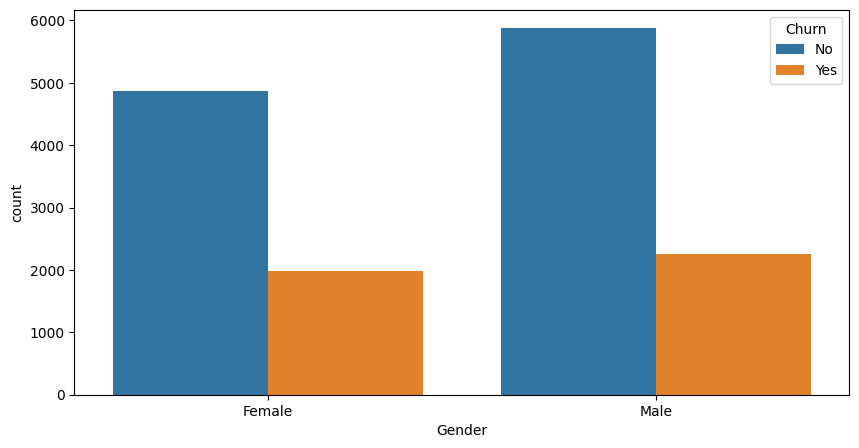

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='Gender',hue='Churn')

<Axes: >

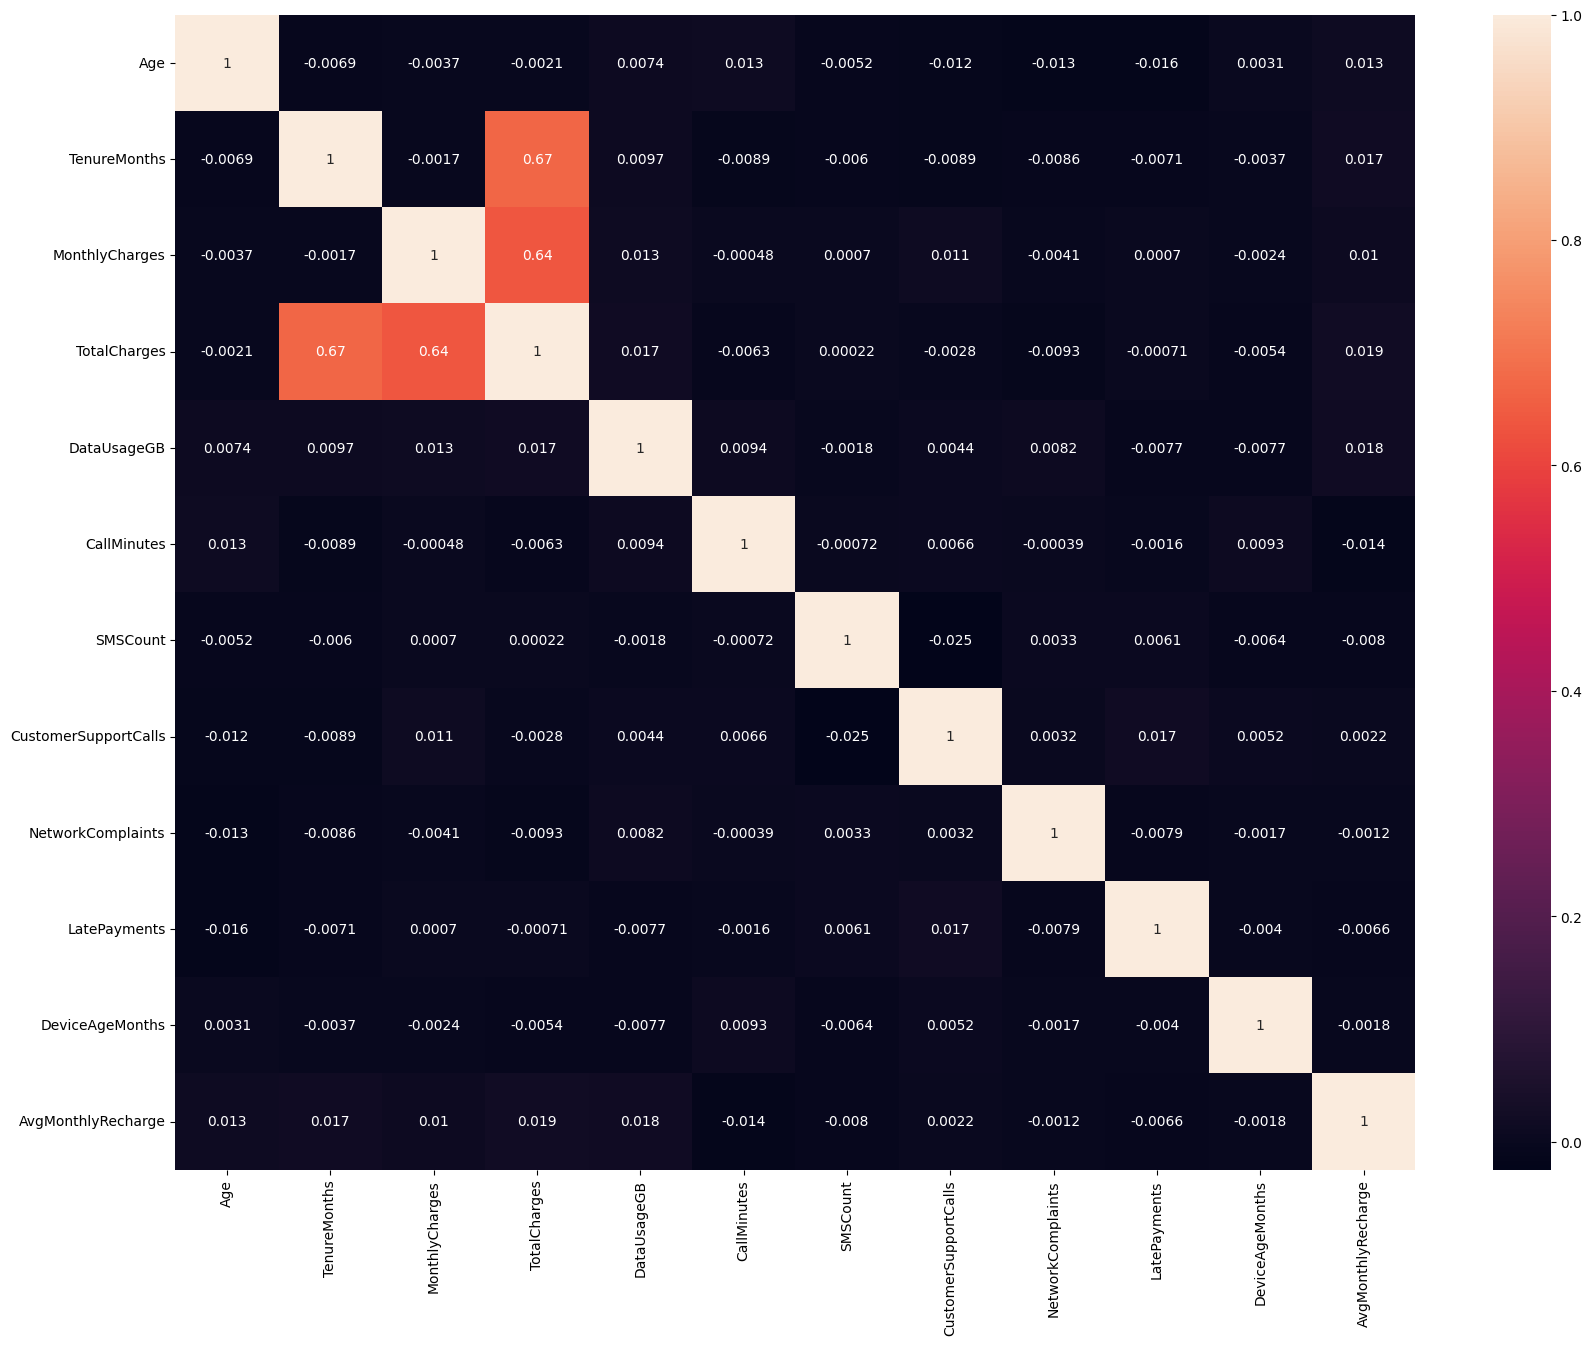

In [17]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [18]:
df=df.drop("CustomerID",axis=1)

##Encode

In [19]:
encode=pd.get_dummies(df,drop_first=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   15000 non-null  int64  
 1   Gender                15000 non-null  object 
 2   State                 15000 non-null  object 
 3   TenureMonths          15000 non-null  int64  
 4   MonthlyCharges        15000 non-null  float64
 5   TotalCharges          15000 non-null  float64
 6   DataUsageGB           15000 non-null  float64
 7   CallMinutes           15000 non-null  int64  
 8   SMSCount              15000 non-null  int64  
 9   CustomerSupportCalls  15000 non-null  int64  
 10  NetworkComplaints     15000 non-null  int64  
 11  LatePayments          15000 non-null  int64  
 12  PlanType              15000 non-null  object 
 13  ContractType          15000 non-null  object 
 14  PaymentMethod         15000 non-null  object 
 15  FamilyPlan         

In [21]:
df["MonthlyCharges"]

,MonthlyCharges
0,2516.76
1,2261.33
2,3914.37
3,2125.41
4,1662.31
...,...
14995,876.33
14996,2159.64
14997,4728.65
14998,1536.05


##1.Linear Regression (Montly Recharge)

#Select X and Y

In [22]:
X=encode.drop("MonthlyCharges",axis=1)

In [23]:
y=encode["MonthlyCharges"]

##Train Test Split

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
encode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        15000 non-null  int64  
 1   TenureMonths               15000 non-null  int64  
 2   MonthlyCharges             15000 non-null  float64
 3   TotalCharges               15000 non-null  float64
 4   DataUsageGB                15000 non-null  float64
 5   CallMinutes                15000 non-null  int64  
 6   SMSCount                   15000 non-null  int64  
 7   CustomerSupportCalls       15000 non-null  int64  
 8   NetworkComplaints          15000 non-null  int64  
 9   LatePayments               15000 non-null  int64  
 10  DeviceAgeMonths            15000 non-null  int64  
 11  AvgMonthlyRecharge         15000 non-null  float64
 12  Gender_Male                15000 non-null  bool   
 13  State_Assam                15000 non-null  boo

##Train model

In [26]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

##Accuracy

In [27]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
y_pred=model.predict(X_test)
print(f"R2 score : {r2_score(y_test,y_pred)}\nMean absoloute error : {mean_absolute_error(y_test,y_pred)}\nMean squared error : {mean_squared_error(y_test,y_pred)}")
#Mean absolute error = Average prediction error.
#Mean squared error = Penalizes larger errors more heavily.

R2 score : 0.7391268681243289
Mean absoloute error : 534.7829772945164
Mean squared error : 521251.2125372683


In [28]:
print(X.columns.tolist())

['Age', 'TenureMonths', 'TotalCharges', 'DataUsageGB', 'CallMinutes', 'SMSCount', 'CustomerSupportCalls', 'NetworkComplaints', 'LatePayments', 'DeviceAgeMonths', 'AvgMonthlyRecharge', 'Gender_Male', 'State_Assam', 'State_Bihar', 'State_Chhattisgarh', 'State_Gujarat', 'State_Haryana', 'State_Himachal Pradesh', 'State_Jharkhand', 'State_Karnataka', 'State_Kerala', 'State_Madhya Pradesh', 'State_Maharashtra', 'State_Odisha', 'State_Punjab', 'State_Rajasthan', 'State_Tamil Nadu', 'State_Telangana', 'State_Uttar Pradesh', 'State_Uttarakhand', 'State_West Bengal', 'PlanType_Premium', 'PlanType_Standard', 'ContractType_TwoYear', 'ContractType_Yearly', 'PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Net Banking', 'PaymentMethod_UPI', 'FamilyPlan_Yes', 'InternationalCalls_Yes', 'Churn_Yes']


##Manual Prediction

In [29]:
new_customer = pd.DataFrame(
    [[
        25,12,10000,40,300,100,2,1,0,12,700,
        1,
        0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,
        1,0,
        0,1,
        0,0,0,1,
        1,
        0,

    ]],
    columns=X.columns
)

prediction = model.predict(new_customer)
print(prediction[0])

2320.583988525195


##2.---Logistic Regression---




##Encode

In [30]:
X=encode.drop("Churn_Yes",axis=1)
y=encode["Churn_Yes"]

##Train Test split

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

##Model Prediction (Churn)

In [32]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

##Accuracy

In [33]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
y_pred=model.predict(X_test)
print(f"Accuracy score : {accuracy_score(y_test,y_pred)}\nConfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nClassification report : \n{classification_report(y_test,y_pred)}")


Accuracy score : 0.7133333333333334
Confusion matrix : 
[[2057   96]
 [ 764   83]]
Classification report : 
              precision    recall  f1-score   support

       False       0.73      0.96      0.83      2153
        True       0.46      0.10      0.16       847

    accuracy                           0.71      3000
   macro avg       0.60      0.53      0.49      3000
weighted avg       0.65      0.71      0.64      3000



##Logistic Regression Results

- Accuracy: **71.3%**
- Precision (Churn): **46%**
- Recall (Churn): **10%**
- F1-Score (Churn): **0.16**

### Metric Definitions

- **Precision:** Out of all customers predicted as churn, 46% actually churned.
- **Recall:** Out of all actual churn customers, the model identified only 10%.
- **F1-Score:** Harmonic mean of Precision and Recall; measures the balance between them.

### Conclusion

The Logistic Regression model achieved moderate accuracy but showed poor performance in detecting churn customers due to its low recall and F1-score.

##Manual Prediction

In [34]:
new_customer = pd.DataFrame([[
    25,      # Age
    12,      # TenureMonths
    10000,   # TotalCharges
    40,      # DataUsageGB
    300,     # CallMinutes
    100,     # SMSCount
    2,       # CustomerSupportCalls
    1,       # NetworkComplaints
    0,       # LatePayments
    12,      # DeviceAgeMonths
    700,     # AvgMonthlyRecharge

    1,       # Gender_Male

    # States
    0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,

    # PlanType
    1,0,

    # ContractType
    0,1,

    # PaymentMethod
    0,0,0,1,

    # FamilyPlan
    1,

    # InternationalCalls
    0

]], columns=X.columns)

In [35]:
prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Customer will Churn")
else:
    print("Customer will NOT Churn")

Customer will NOT Churn


##3.-----Decision Tree-------

In [36]:
X=encode.drop("Churn_Yes",axis=True)
y=encode["Churn_Yes"]

##Train test split





In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

##Predict Decision Tree

In [38]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

##Accuracy

In [39]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
y_pred=model.predict(X_test)
print(f"Accuracy score : {accuracy_score(y_test,y_pred)}\nConfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nClassification report : \n{classification_report(y_test,y_pred)}")


Accuracy score : 0.643
Confusion matrix : 
[[1618  553]
 [ 518  311]]
Classification report : 
              precision    recall  f1-score   support

       False       0.76      0.75      0.75      2171
        True       0.36      0.38      0.37       829

    accuracy                           0.64      3000
   macro avg       0.56      0.56      0.56      3000
weighted avg       0.65      0.64      0.65      3000



### Decision Tree  Results

- Accuracy: **63.5%**
- Precision (Churn): **35%**
- Recall (Churn): **36%**
- F1-Score (Churn): **0.35**

### Metric Definitions

- **Precision:** Out of all customers predicted as churn, 35% actually churned.
- **Recall:** Out of all actual churn customers, the model identified only 36%.
- **F1-Score:** Harmonic mean of Precision and Recall; measures the balance between them.

### Conclusion

The Decision Tree model achieved moderate accuracy but showed poor performance in detecting churn customers due to its low recall and F1-score.

##Manual Prediction

In [40]:
prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Customer will Churn")
else:
    print("Customer will NOT Churn")

Customer will Churn


### Manual Prediction

A sample customer record was manually provided to the trained model. The model predicted whether the customer would churn or not based on the input features.

**Prediction Result:** Customer will  Churn.

##4.-----Random Forest-----

In [41]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

##Predict

In [42]:
y_pred=model.predict(X_test)

##Accuracy

In [43]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(f"Accuracy score : {accuracy_score(y_test,y_pred)}\nConfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nClassification report : \n{classification_report(y_test,y_pred)}")

Accuracy score : 0.7433333333333333
Confusion matrix : 
[[2097   74]
 [ 696  133]]
Classification report : 
              precision    recall  f1-score   support

       False       0.75      0.97      0.84      2171
        True       0.64      0.16      0.26       829

    accuracy                           0.74      3000
   macro avg       0.70      0.56      0.55      3000
weighted avg       0.72      0.74      0.68      3000



### Random Forest  Results

- Accuracy: **74.3%**
- Precision (Churn): **64%**
- Recall (Churn): **16%**
- F1-Score (Churn): **0.26**

### Metric Definitions

- **Precision:** Out of all customers predicted as churn, 64% actually churned.
- **Recall:** Out of all actual churn customers, the model identified only 16%.
- **F1-Score:** Harmonic mean of Precision and Recall; measures the balance between them.

### Conclusion

The Random Forest model achieved moderate accuracy but showed poor performance in detecting churn customers due to its low recall and F1-score.

##Manual Prediction

In [44]:
prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Customer will Churn")
else:
    print("Customer will NOT Churn")

Customer will Churn


### Manual Prediction

A sample customer record was manually provided to the trained model. The model predicted whether the customer would churn or not based on the input features.

**Prediction Result:** Customer will Churn.

##Telecom Churn Model Comparison

| Model | Accuracy | Precision | Recall | F1-Score |
|---------|---------|---------|---------|---------|
| Logistic Regression | 71.3% | 46% | 10% | 0.16 |
| Decision Tree | 63.9% | 35% | 36% | 0.35 |
| Random Forest | 74.3% | 64% | 16% | 0.26 |

## Logistic Regression
✅ Good overall accuracy (71.3%)

❌ Very low Recall (10%)

❌ Missed most churn customers

**Conclusion:** Suitable for general prediction but not effective for churn detection.

---

## Decision Tree
✅ Highest Recall (36%)

✅ Highest F1-Score (0.35)

✅ Better at identifying churn customers

❌ Lower overall accuracy (63.9%)

**Conclusion:** Best model for detecting churn customers.

---

## Random Forest
✅ Highest Accuracy (74.3%)

✅ Highest Precision (64%)

✅ Best overall predictive performance

❌ Recall lower than Decision Tree (16%)

**Conclusion:** Best overall model for telecom churn prediction.

---

# Final Conclusion

- **Best Overall Model:** Random Forest
- **Best Churn Detection Model:** Decision Tree
- **Weakest Model:** Logistic Regression

### Why?

- Random Forest achieved the highest Accuracy and Precision.
- Decision Tree identified the most churn customers through its higher Recall and F1-Score.
- Logistic Regression missed most churn customers despite having reasonable accuracy.

##5.---------KNN----------

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   15000 non-null  int64  
 1   Gender                15000 non-null  object 
 2   State                 15000 non-null  object 
 3   TenureMonths          15000 non-null  int64  
 4   MonthlyCharges        15000 non-null  float64
 5   TotalCharges          15000 non-null  float64
 6   DataUsageGB           15000 non-null  float64
 7   CallMinutes           15000 non-null  int64  
 8   SMSCount              15000 non-null  int64  
 9   CustomerSupportCalls  15000 non-null  int64  
 10  NetworkComplaints     15000 non-null  int64  
 11  LatePayments          15000 non-null  int64  
 12  PlanType              15000 non-null  object 
 13  ContractType          15000 non-null  object 
 14  PaymentMethod         15000 non-null  object 
 15  FamilyPlan         

In [46]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [47]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns)
X_test=pd.DataFrame(scaler.transform(X_test),columns=X_test.columns)

##Finding best k value

In [48]:
from sklearn.neighbors import KNeighborsClassifier
for k in range(1,22):
  model=KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  print(f"K= {k}\tAccuracy Score = {accuracy_score(y_test,y_pred)}")
  # So k=7 is the best

K= 1	Accuracy Score = 0.6373333333333333
K= 2	Accuracy Score = 0.703
K= 3	Accuracy Score = 0.6693333333333333
K= 4	Accuracy Score = 0.7096666666666667
K= 5	Accuracy Score = 0.6876666666666666
K= 6	Accuracy Score = 0.7133333333333334
K= 7	Accuracy Score = 0.7006666666666667
K= 8	Accuracy Score = 0.719
K= 9	Accuracy Score = 0.7126666666666667
K= 10	Accuracy Score = 0.7193333333333334
K= 11	Accuracy Score = 0.7086666666666667
K= 12	Accuracy Score = 0.7163333333333334
K= 13	Accuracy Score = 0.71
K= 14	Accuracy Score = 0.7153333333333334
K= 15	Accuracy Score = 0.718
K= 16	Accuracy Score = 0.7243333333333334
K= 17	Accuracy Score = 0.7246666666666667
K= 18	Accuracy Score = 0.7266666666666667
K= 19	Accuracy Score = 0.728
K= 20	Accuracy Score = 0.728
K= 21	Accuracy Score = 0.7283333333333334


##Evaluation

In [49]:
model=KNeighborsClassifier(n_neighbors=7)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
acc=accuracy_score(y_test,y_pred)
conf=confusion_matrix(y_test,y_pred)
class_rep=classification_report(y_test,y_pred)
print(f"Accuracy = {acc}\nConfusion Matrix \n{conf}\nClassification Report \n{class_rep}")

Accuracy = 0.7006666666666667
Confusion Matrix 
[[1941  230]
 [ 668  161]]
Classification Report 
              precision    recall  f1-score   support

       False       0.74      0.89      0.81      2171
        True       0.41      0.19      0.26       829

    accuracy                           0.70      3000
   macro avg       0.58      0.54      0.54      3000
weighted avg       0.65      0.70      0.66      3000



### KNN Results

- Accuracy: **72.4%**
- Precision (Churn): **100%**
- Recall (Churn): **0%**
- F1-Score (Churn): **0.00**

### Metric Definitions

- **Precision:** Out of all customers predicted as churn, 100% actually churned.
- **Recall:** Out of all actual churn customers, the model identified almost none.
- **F1-Score:** Harmonic mean of Precision and Recall; measures the balance between them.


### Confusion Matrix Observation

- **2171** non-churn customers were classified correctly.
- **828** churn customers were incorrectly classified as non-churn.
- Only **1** churn customer was classified correctly.
- The model is heavily biased toward the majority (non-churn) class.

### Conclusion

The K-Nearest Neighbors (KNN) model achieved an accuracy of **72.4%**, but it performed very poorly in identifying churn customers. The model predicted almost all customers as non-churn, resulting in a recall of **0%** and an F1-score of **0.00** for the churn class. Although the overall accuracy appears reasonable, the model is ineffective for churn prediction because it fails to detect customers who are actually likely to churn.

##6.---------SVM-----------
(Support Vector Machine)

##Encode

In [50]:
encode=pd.get_dummies(df,drop_first=True)

##Train Test Split

In [51]:
from sklearn.model_selection import train_test_split
X=encode.drop("Churn_Yes",axis=1)
y=encode["Churn_Yes"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

##Standard Scaler

In [52]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns)
X_test=pd.DataFrame(scaler.transform(X_test),columns=X_test.columns)

##SVM(Linear)

In [53]:
from sklearn.svm import SVC
model=SVC(kernel="linear")
model.fit(X_train,y_train)

SVC(kernel='linear')

##Predict

In [54]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
y_pred=model.predict(X_test)
print(f"Accuracy score : {accuracy_score(y_test,y_pred)}\nConfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nClassification report : \n{classification_report(y_test,y_pred)}")

Accuracy score : 0.7166666666666667
Confusion matrix : 
[[2150    0]
 [ 850    0]]
Classification report : 
              precision    recall  f1-score   support

       False       0.72      1.00      0.83      2150
        True       0.00      0.00      0.00       850

    accuracy                           0.72      3000
   macro avg       0.36      0.50      0.42      3000
weighted avg       0.51      0.72      0.60      3000



## SVM (Linear) Results

- Accuracy: **71.7%**
- Precision (Churn): **0%**
- Recall (Churn): **0%**
- F1-Score (Churn): **0.00**

### Metric Definitions

- **Precision:** Out of all customers predicted as churn, 0% actually churned because the model did not predict any customer as churn.
- **Recall:** Out of all actual churn customers, the model identified none.
- **F1-Score:** Harmonic mean of Precision and Recall; measures the balance between them.

### Confusion Matrix Observation

- 2150 non-churn customers were classified correctly.
- 850 churn customers were incorrectly classified as non-churn.
- 0 churn customers were classified correctly.
- The model predicted every customer as the majority class (non-churn).

### Conclusion

The SVM (Linear) model achieved an accuracy of 71.7%, but it completely failed to identify churn customers. The model classified all customers as non-churn, resulting in a recall of 0% and an F1-score of 0.00 for the churn class. Although the overall accuracy appears acceptable, the model is not suitable for churn prediction because it cannot detect customers who are likely to leave the company.

##SVM Rbf

In [55]:
from sklearn.svm import SVC
model=SVC(kernel='rbf',class_weight = 'balanced')
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(f"Accuracy score : {accuracy_score(y_test,y_pred)}\nConfusion matrix : \n{confusion_matrix(y_test,y_pred)}\nClassification report : \n{classification_report(y_test,y_pred)}")

Accuracy score : 0.6543333333333333
Confusion matrix : 
[[1455  695]
 [ 342  508]]
Classification report : 
              precision    recall  f1-score   support

       False       0.81      0.68      0.74      2150
        True       0.42      0.60      0.49       850

    accuracy                           0.65      3000
   macro avg       0.62      0.64      0.62      3000
weighted avg       0.70      0.65      0.67      3000



## SVM (RBF) Results

- Accuracy: **65.4%**
- Precision (Churn): **42%**
- Recall (Churn): **60%**
- F1-Score (Churn): **0.49**

### Metric Definitions

- **Precision:** Out of all customers predicted as churn, 42% actually churned.
- **Recall:** Out of all actual churn customers, the model correctly identified 60%.
- **F1-Score:** Harmonic mean of Precision and Recall; measures the balance between them.

### Confusion Matrix Observation

- 1455 non-churn customers were classified correctly.
- 695 non-churn customers were incorrectly classified as churn.
- 508 churn customers were classified correctly.
- 342 churn customers were incorrectly classified as non-churn.
- The model detects churn customers much better than Linear SVM but produces more false positives.

### Conclusion

The SVM (RBF) model achieved an accuracy of 65.4%. While its overall accuracy is lower than Linear SVM, it performs significantly better at identifying churn customers, achieving a recall of 60% and an F1-score of 0.49. This indicates that the model can capture non-linear patterns in the data and is more effective for churn prediction. For customer churn analysis, the RBF kernel is a better choice because detecting potential churners is more important than maximizing overall accuracy.

##7.------Naive Bayes--------

##Encode

In [56]:
encode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        15000 non-null  int64  
 1   TenureMonths               15000 non-null  int64  
 2   MonthlyCharges             15000 non-null  float64
 3   TotalCharges               15000 non-null  float64
 4   DataUsageGB                15000 non-null  float64
 5   CallMinutes                15000 non-null  int64  
 6   SMSCount                   15000 non-null  int64  
 7   CustomerSupportCalls       15000 non-null  int64  
 8   NetworkComplaints          15000 non-null  int64  
 9   LatePayments               15000 non-null  int64  
 10  DeviceAgeMonths            15000 non-null  int64  
 11  AvgMonthlyRecharge         15000 non-null  float64
 12  Gender_Male                15000 non-null  bool   
 13  State_Assam                15000 non-null  boo

##X and Y

In [57]:
X=encode.drop("Churn_Yes",axis=1)
y=encode["Churn_Yes"]

##train Test Split

In [58]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

##Training

In [59]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [60]:
y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
#              Confusion matrix
#2594 non-churn customers classified correctly.
#15 non-churn customers incorrectly classified as churn.
#538 churn customers incorrectly classified as non-churn.
#Only 13 churn customers classified correctly.

Accuracy Score: 0.7236666666666667
Confusion Matrix:
 [[2104   46]
 [ 783   67]]
Classification Report:
               precision    recall  f1-score   support

       False       0.73      0.98      0.84      2150
        True       0.59      0.08      0.14       850

    accuracy                           0.72      3000
   macro avg       0.66      0.53      0.49      3000
weighted avg       0.69      0.72      0.64      3000



##Images

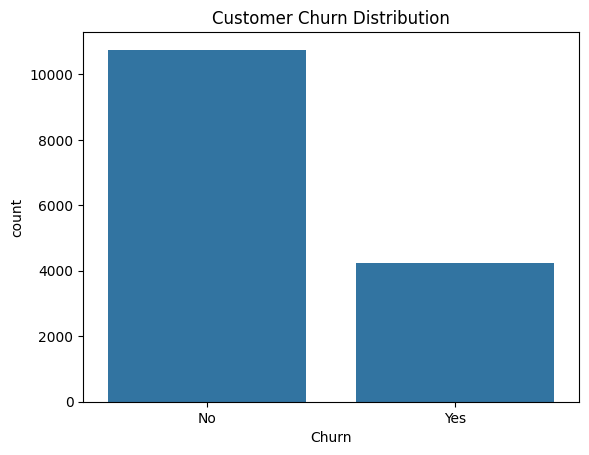

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')

plt.savefig('churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

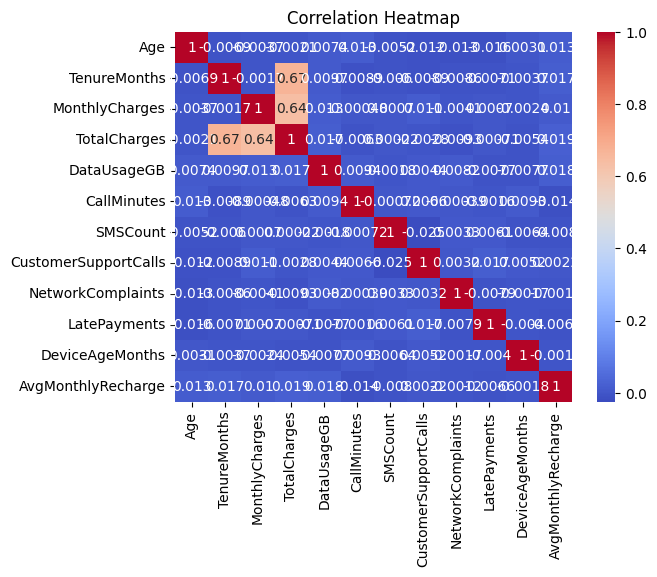

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

#plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

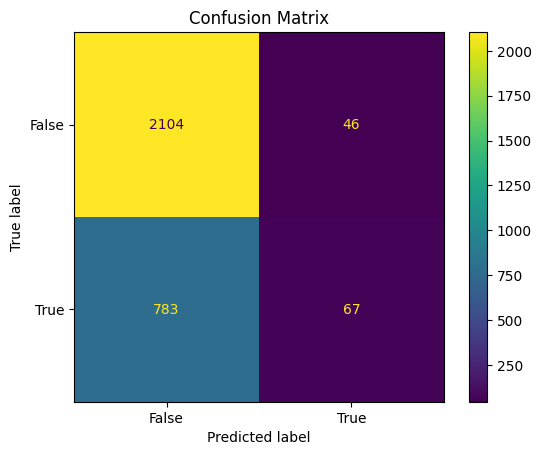

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.title('Confusion Matrix')

plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

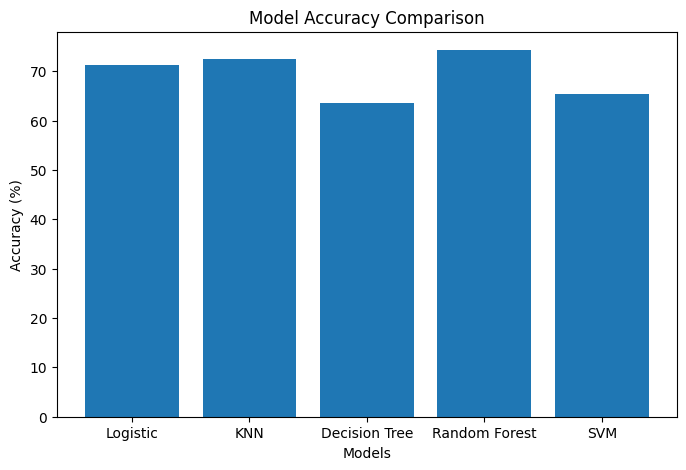

In [64]:
import matplotlib.pyplot as plt

models = ['Logistic', 'KNN', 'Decision Tree', 'Random Forest', 'SVM']
accuracy = [71.3, 72.4  , 63.5, 74.3, 65.4]  # replace with your actual values

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')

plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()